# 6. Kerr rings and chains: accuracy at $K=3$ and polynomial cost — Fig. 8 (Sec. VI)

$K$ driven Kerr cavities, $\Delta=-\kappa$, $J=0.4\kappa$, $\eta=\kappa$. The linear ring is Gaussian: a uniform displacement plus a Fourier transform diagonalizes $\mathcal L_0$ once for every $K$, and the Kerr term becomes a momentum-conserving vertex. With disorder the momentum modes become numerically diagonalized normal modes and the vertex a dense tensor (`tensor_engine.py`), which prunes at every vertex the degree sectors the remaining vertices cannot bring back to the steady state. Exact steady states are available only up to $K\approx4$–$5$.

**Part A** runs the calculation here: the $K=1$ and $K=3$ cross-checks between engines (SM Table SII), the $K=3$ series against the exact steady state, a small timing scan, and a disordered ten-site chain with site-resolved $g^{(2)}$ and $g^{(3)}$ against the HFB closure. **Part B** regenerates Fig. 8 from the stored series (`ring_trunc.py`), exact references (`exact_pool.py`, `exact_disp_pool.py`; hours at the converged cutoffs), the single-core timing pass (`timing_v3.py`, on a quiet node) and the label counts (`label_counts.py`), and prints the numbers of Sec. VI.

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A1 — engine cross-checks and the $K=3$ ring

K=1 cross-check   multimode: [0.8        0.9536     1.0160384  1.04761242 1.06585224]
                 single mode: [0.8        0.9536     1.0160384  1.04761242 1.06585224]


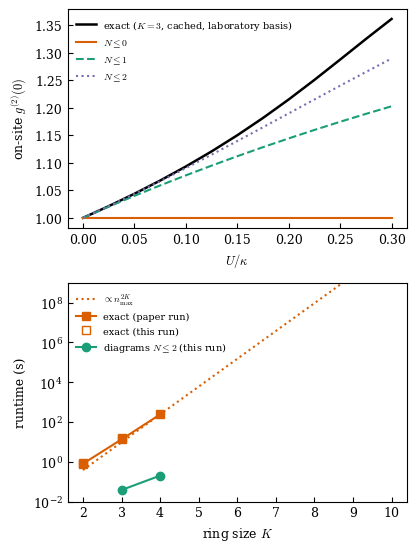

g2 error at U=0.15, N<=2: 0.01049


In [2]:
import multimode as MM
from ring_ss_evolve import ring_steady_evolve
P = dict(kappa=1.0, Delta=-1.0, J=0.4, eta=1.0)
r1 = MM.Ring(K=1, kappa=1.0, Delta=-1.0, J=0.0, eta=1.0, U=0.15)
a0,ad0 = r1.site_ops(0)
z1 = 0.5-1j; al1 = 1/z1
A1,Ad1,_,_ = mode_ops(al1)
mod1 = Model(1, z1, lambda X: 0*X, np.eye(1), scale(0.15/2, mul(mul(Ad1,Ad1),mul(A1,A1))), 4)
print("K=1 cross-check   multimode:", np.round(np.cumsum(r1.series(MM.mul(ad0,a0),4)).real,8))
print("                 single mode:", np.round(np.cumsum(moment_series(mod1,1,1,al1,4)).real,8))
Us = np.linspace(0,0.3,13); exU = json.load(open(os.path.join(DATA, 'ring_exactU.json')))
g2_ser = []
for U in Us:
    r = MM.Ring(K=3,U=U,**P); b0,bd0 = r.site_ops(0)
    n = np.cumsum(r.series(MM.mul(bd0,b0),2)).real
    n2 = np.cumsum(r.series(MM.mul(MM.mul(bd0,bd0),MM.mul(b0,b0)),2)).real
    g2_ser.append(n2/n**2)
g2_ser = np.array(g2_ser)
exG = np.array([exU[f"{U:.3f}"]["n0n0"]/exU[f"{U:.3f}"]["n0"]**2 for U in Us])
Ks = [3,4] if FAST else [3,4,5,6]; td=[]
for K in Ks:
    t=time.time(); r=MM.Ring(K=K,U=0.15,**P); b0,bd0=r.site_ops(0); r.series(MM.mul(bd0,b0),2); td.append(time.time()-t)
te = {}
for K,nm in [(2,8),(3,6)]:
    t=time.time(); ring_steady_evolve(K,U=0.15,nmax=nm,**P); te[K]=time.time()-t
paper_exact = json.load(open(os.path.join(DATA, 'ring_timing.json')))["exact"]
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(4.2,5.6))
ax1.plot(Us,exG,'k-',lw=1.8,label='exact ($K=3$, cached, laboratory basis)')
for c,N,ls in zip(COL,[0,1,2],['-','--',':']): ax1.plot(Us,g2_ser[:,N],color=c,ls=ls,label=f'$N\\leq{N}$')
ax1.set_xlabel('$U/\\kappa$'); ax1.set_ylabel('on-site $g^{(2)}(0)$'); ax1.legend(fontsize=7)
Kall=np.arange(2,11)
ax2.semilogy(Kall, float(paper_exact["4"])*5.0**(2*(Kall-4)),':',color=COL[0],label=r'$\propto n_{\max}^{2K}$')
ax2.semilogy([int(k) for k in paper_exact],[float(v) for v in paper_exact.values()],'s-',color=COL[0],label='exact (paper run)')
ax2.semilogy(list(te),list(te.values()),'s',mfc='none',color=COL[0],label='exact (this run)')
ax2.semilogy(Ks,td,'o-',color=COL[1],label='diagrams $N\\leq2$ (this run)')
ax2.set_ylim(1e-2,1e9); ax2.set_xlabel('ring size $K$'); ax2.set_ylabel('runtime (s)'); ax2.legend(fontsize=7)
fig.tight_layout(); plt.show()
print("g2 error at U=0.15, N<=2:", round(abs(g2_ser[6,2]-exG[6]),5))

## Part A2 — disorder: tensor engine, site-resolved $g^{(2)}$ and $g^{(3)}$ against the HFB closure

K=3 uniform cross-check  momentum: [0.286533 0.299236 0.30194 ]
                           tensor: [0.286533 0.299236 0.30194 ]


K=10, order 2, all sites: 2 s


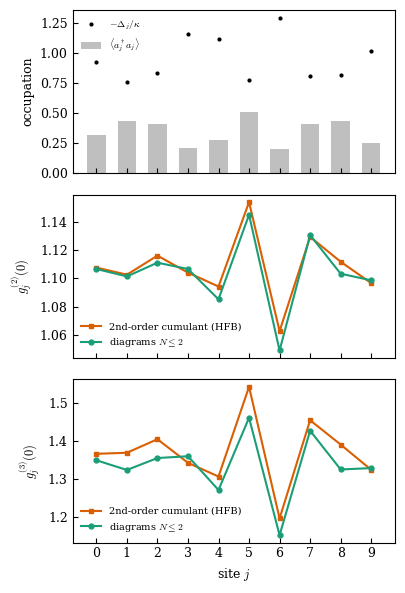

In [3]:
import tensor_engine as TE
from hfb_chain import hfb_chain
r3 = MM.Ring(K=3,U=0.15,**P); b0,bd0 = r3.site_ops(0)
ch3 = TE.Chain(3,1.0,[-1.0]*3,0.4,1.0,0.15)
a3_,ad3_ = ch3.site_a(0), ch3.site_ad(0)
print("K=3 uniform cross-check  momentum:", np.round(np.cumsum(r3.series(MM.mul(bd0,b0),2)).real,6))
print("                           tensor:", np.round(np.cumsum(ch3.series(TE.mul(ad3_,a3_),2)).real,6))
rng = np.random.default_rng(7); K = 10; det = -1.0+0.3*rng.uniform(-1,1,K); U = 0.15
ch = TE.Chain(K,1.0,det,0.4,1.0,U); h,_ = hfb_chain(K,1.0,det,0.4,1.0,U)
Nord = 2 if FAST else 4
n_,g2_,g3_ = [],[],[]
t0=time.time()
for j in range(K):
    a_,ad_ = ch.site_a(j), ch.site_ad(j)
    n = np.cumsum(ch.series(TE.mul(ad_,a_),Nord)).real
    n2 = np.cumsum(ch.series(TE.mul(TE.mul(ad_,ad_),TE.mul(a_,a_)),Nord)).real
    n3 = np.cumsum(ch.series(TE.mul(TE.mul(TE.mul(ad_,ad_),ad_),TE.mul(TE.mul(a_,a_),a_)),Nord)).real
    n_.append(n[Nord]); g2_.append(n2[Nord]/n[Nord]**2); g3_.append(n3[Nord]/n[Nord]**3)
print(f"K={K}, order {Nord}, all sites: {time.time()-t0:.0f} s")
sites=np.arange(K)
fig,(ax0,ax1,ax2)=plt.subplots(3,1,figsize=(4.2,6.0),sharex=True)
ax0.bar(sites,n_,color='0.75',width=0.6,label=r'$\langle a_j^\dagger a_j\rangle$'); ax0.plot(sites,-det,'k.',ms=4,label=r'$-\Delta_j/\kappa$')
ax0.set_ylabel('occupation'); ax0.legend(fontsize=7)
ax1.plot(sites,[h[j]['g2'] for j in sites],'s-',color=COL[0],ms=3.5,label='2nd-order cumulant (HFB)')
ax1.plot(sites,g2_,'o-',color=COL[1],ms=3.5,label=f'diagrams $N\\leq{Nord}$')
ax1.set_ylabel('$g^{(2)}_j(0)$'); ax1.legend(fontsize=7)
ax2.plot(sites,[h[j]['g3'] for j in sites],'s-',color=COL[0],ms=3.5,label='2nd-order cumulant (HFB)')
ax2.plot(sites,g3_,'o-',color=COL[1],ms=3.5,label=f'diagrams $N\\leq{Nord}$')
ax2.set_ylabel('$g^{(3)}_j(0)$'); ax2.set_xlabel('site $j$'); ax2.set_xticks(sites); ax2.legend(fontsize=7)
fig.tight_layout(); plt.show()

## Part B — Fig. 8 of the paper and the numbers of Sec. VI

`assemble_truncation.py` applies the truncation rule to the stored $K=3$ series, compares with the converged displaced-frame exact reference, fits the timing pass, and redraws the figure.

$ (cd code/benchmarks/truncation; python3 assemble_truncation.py)   [8.0 s, exit 0]
 }
}
assembled


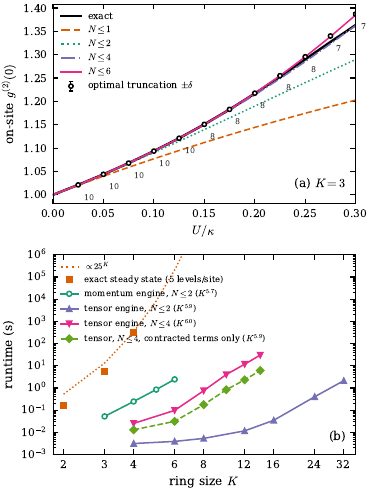

In [4]:
run("python3 assemble_truncation.py", "benchmarks/truncation", timeout=600)
paper_figure("benchmarks/truncation/fig_ring.pdf")

In [5]:
T = J("benchmarks", "truncation", "truncation_results.json"); R = T["ring_K3"]["results"]
r = R["0.150"]; e = lambda U, N: abs(R[U]["n"]["partial_sums"][N]-R[U]["n"]["exact"])/R[U]["n"]["exact"]
print("Sec. VI, accuracy at K=3")
quoted("n: second-order relative error at U=0.05 (%)", 0.01, 100*e("0.050", 2), "{:.2f}")
quoted("n: second-order relative error at U=0.15 (%)", 0.3, 100*e("0.150", 2), "{:.1f}")
quoted("n: second-order relative error at U=0.30 (%)", 3, 100*e("0.300", 2), "{:.1f}")
quoted("U=0.15: exact n0 / g2", "0.3029 / 1.151", f"{r['n']['exact']:.4f} / {r['g2']['exact']:.3f}")
quoted("U=0.15: second order n0 / g2", "0.3019 / 1.140", f"{r['n']['partial_sums'][2]:.4f} / {r['g2']['partial_sums'][2]:.3f}")
quoted("U=0.15: fourth order g2", 1.150, r['g2']['partial_sums'][4], "{:.3f}")
quoted("U=0.15: N*, value, delta, true error", "8, 1.1509, 1e-5, 5e-5", f"{r['g2']['N_star']}, {r['g2']['value']:.4f}, {r['g2']['delta']:.0e}, {r['g2']['true_error']:.0e}")
print("\ntrue error / delta:      U    g2     g3        (paper: within 2 for U<=0.125 [g2]; 4 at U=0.15, rising to 12 [g2] and 27 [g3] at U=0.3)")
for U in R:
    if U != "0.000": print(f"                       {U}  {R[U]['g2']['true_error']/R[U]['g2']['delta']:5.2f}  {R[U]['g3']['true_error']/R[U]['g3']['delta']:5.2f}")
P3 = J("benchmarks", "truncation", "summary_numbers.json")["timing_pass3"]; F = T["timing_fits"]
print("\nSec. VI, runtimes on one core (pass 3)")
quoted("exact, 5 levels/site: growth per site", 45, F["pass3:exact_levels5"]["per_site_factor"], "{:.0f}")
quoted("exact, 5 levels/site, K=4 (s)", 328, P3["exact_levels5"]["t"][2], "{:.0f}")
quoted("momentum engine N<=2, K=6 (s) / exponent", "2.4 / 5.7", f"{P3['momentum3_n_unpruned_N2']['t'][-1]:.1f} / {F['pass3:momentum3_n_unpruned_N2']['exponent_last3']:.1f}")
quoted("tensor engine N<=2, K=32 (s) / exponent above K=16", "2.1 / 5.9", f"{P3['te_N2']['t'][-1]:.1f} / {F['pass3:te_N2']['exponent_last3']:.1f}")
quoted("tensor engine N<=4, K=14 (s) / exponent", "30 / 6.0", f"{P3['te_N4']['t'][-1]:.0f} / {F['pass3:te_N4']['exponent_last3']:.1f}")
quoted("tensor engine N<=4, contracted commutator, K=14 (s)", 6.1, P3["te_nz_N4"]["t"][-1], "{:.1f}")
from math import comb, floor
print("\nlabel bound C(2K+Dmax, Dmax), Dmax = 2 floor(N/2 + d0/4), d0 = 4:  " + ", ".join(f"N={N}: K^{2*floor(N/2+1)}" for N in (2,3,4,5)) + "   (paper: K^4 at N=2,3; K^6 at N=4,5)")

Sec. VI, accuracy at K=3
  n: second-order relative error at U=0.05 (%)                   paper         0.01   code         0.01
  n: second-order relative error at U=0.15 (%)                   paper          0.3   code          0.3
  n: second-order relative error at U=0.30 (%)                   paper          3.0   code          3.3
  U=0.15: exact n0 / g2                                          paper 0.3029 / 1.151   code 0.3029 / 1.151
  U=0.15: second order n0 / g2                                   paper 0.3019 / 1.140   code 0.3019 / 1.140
  U=0.15: fourth order g2                                        paper        1.150   code        1.150
  U=0.15: N*, value, delta, true error                           paper 8, 1.1509, 1e-5, 5e-5   code 8, 1.1509, 1e-05, 5e-05

true error / delta:      U    g2     g3        (paper: within 2 for U<=0.125 [g2]; 4 at U=0.15, rising to 12 [g2] and 27 [g3] at U=0.3)
                       0.025   1.21   4.01
                       0.050   0.55   1